<a href="https://colab.research.google.com/github/kiruthigapandi02-max/2026-FDP-DSU/blob/main/Data_Analytics_on_Wine_Dataset.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [21]:
from google.colab import files
uploaded = files.upload()

Saving winequalityN.csv to winequalityN.csv


First 5 Rows
    type  fixed acidity  volatile acidity  citric acid  residual sugar  \
0  white            7.0              0.27         0.36            20.7   
1  white            6.3              0.30         0.34             1.6   
2  white            8.1              0.28         0.40             6.9   
3  white            7.2              0.23         0.32             8.5   
4  white            7.2              0.23         0.32             8.5   

   chlorides  free sulfur dioxide  total sulfur dioxide  density    pH  \
0      0.045                 45.0                 170.0   1.0010  3.00   
1      0.049                 14.0                 132.0   0.9940  3.30   
2      0.050                 30.0                  97.0   0.9951  3.26   
3      0.058                 47.0                 186.0   0.9956  3.19   
4      0.058                 47.0                 186.0   0.9956  3.19   

   sulphates  alcohol  quality  
0       0.45      8.8        6  
1       0.49      9.5        6 

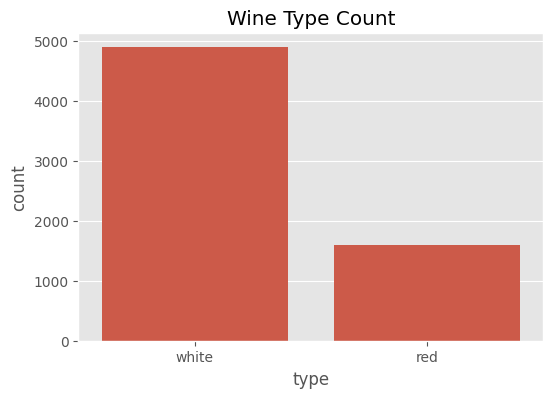

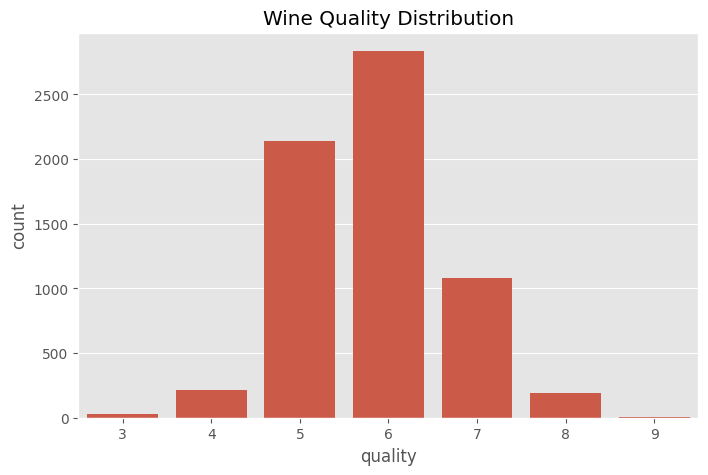

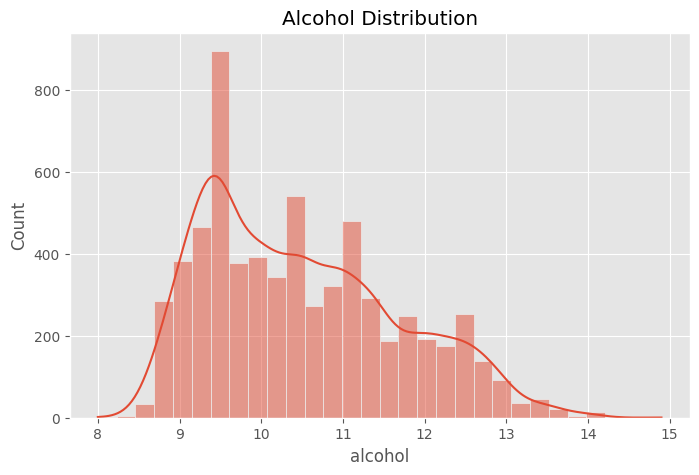

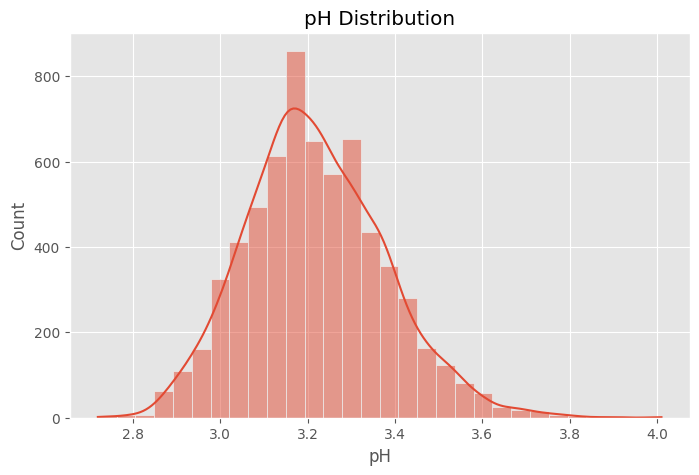

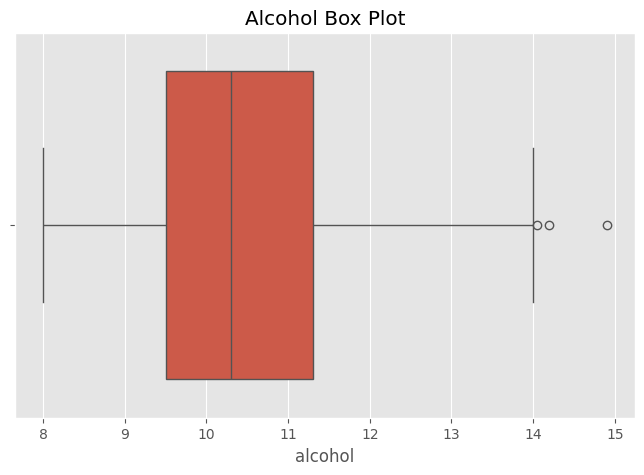

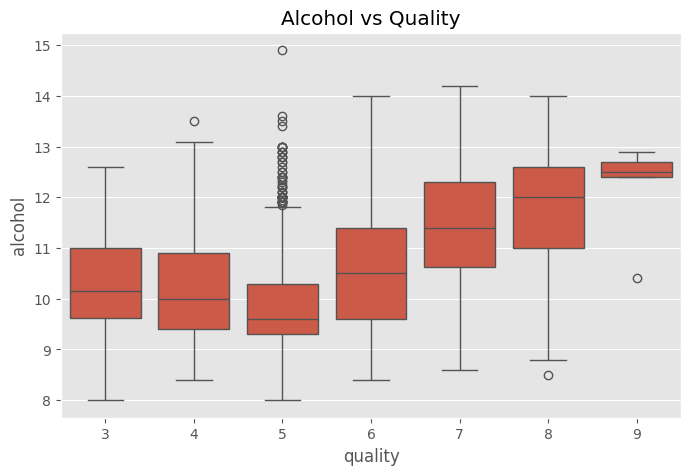

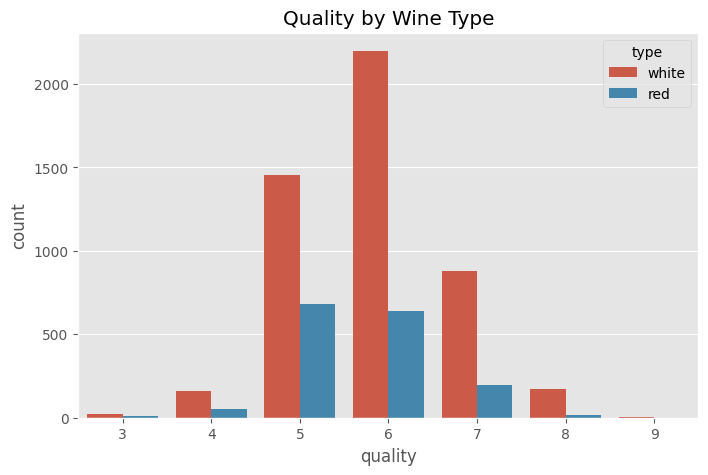

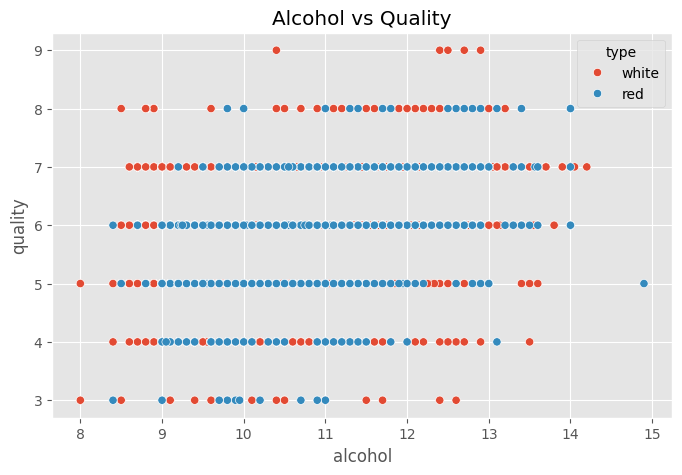

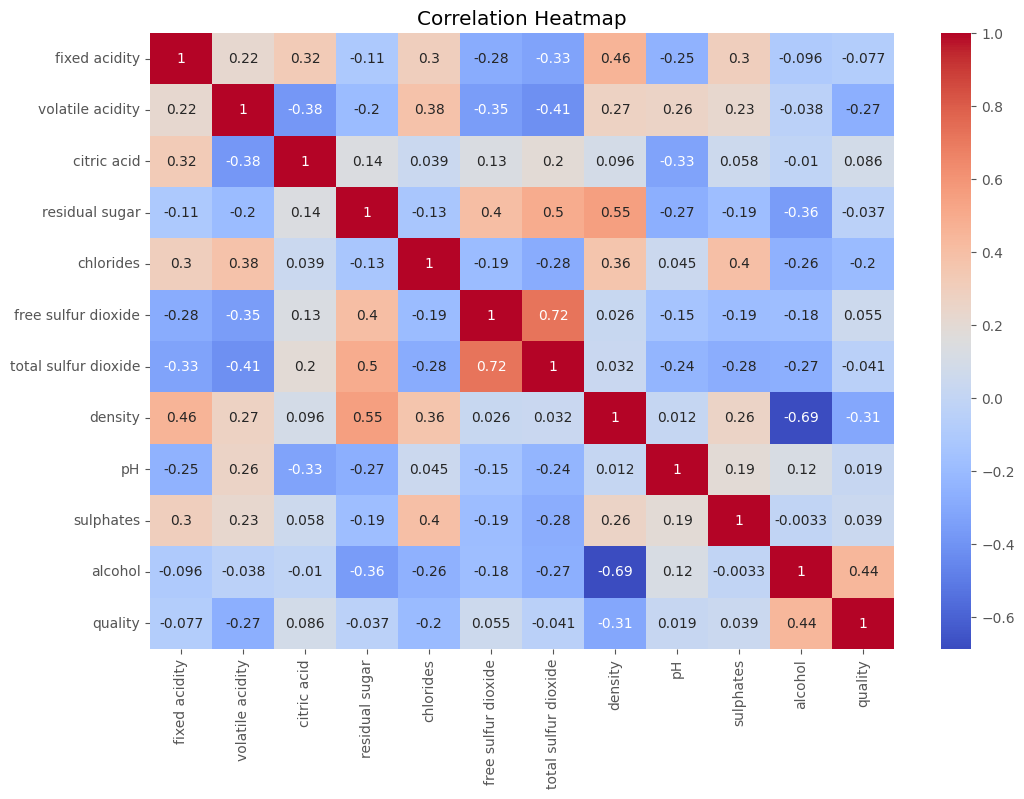


Total Wines : 6497
Average Quality : 5.818377712790519
Maximum Alcohol : 14.9
Minimum Alcohol : 8.0

Average Quality by Wine Type
type
red      5.636023
white    5.877909
Name: quality, dtype: float64

Average Alcohol by Wine Type
type
red      10.422983
white    10.514267
Name: alcohol, dtype: float64

Quality Distribution
quality
3      30
4     216
5    2138
6    2836
7    1079
8     193
9       5
Name: count, dtype: int64


In [22]:
# ==========================================
# WINE QUALITY DATA ANALYTICS (EDA)
# ==========================================

# Step 1: Import Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Step 2: Load Dataset
df = pd.read_csv('winequalityN.csv')  # Change according to your file name

# Step 3: Display First 5 Rows
print("First 5 Rows")
print(df.head())

# Step 4: Dataset Information
print("\nDataset Information")
print(df.info())

# Step 5: Statistical Summary
print("\nStatistical Summary")
print(df.describe())

# Step 6: Check Missing Values
print("\nMissing Values")
print(df.isnull().sum())

# ==========================================
# DATA CLEANING
# ==========================================

# Fill missing values in numerical columns using median
for col in df.select_dtypes(include=['float64', 'int64']).columns:
    df[col] = df[col].fillna(df[col].median())

print("\nMissing Values After Cleaning")
print(df.isnull().sum())

# ==========================================
# EXPLORATORY DATA ANALYSIS (EDA)
# ==========================================

# 1. Wine Type Count
plt.figure(figsize=(6,4))
sns.countplot(x='type', data=df)
plt.title('Wine Type Count')
plt.show()

# 2. Quality Distribution
plt.figure(figsize=(8,5))
sns.countplot(x='quality', data=df)
plt.title('Wine Quality Distribution')
plt.show()

# 3. Alcohol Distribution
plt.figure(figsize=(8,5))
sns.histplot(df['alcohol'], bins=30, kde=True)
plt.title('Alcohol Distribution')
plt.show()

# 4. pH Distribution
plt.figure(figsize=(8,5))
sns.histplot(df['pH'], bins=30, kde=True)
plt.title('pH Distribution')
plt.show()

# 5. Alcohol Box Plot
plt.figure(figsize=(8,5))
sns.boxplot(x=df['alcohol'])
plt.title('Alcohol Box Plot')
plt.show()

# 6. Alcohol vs Quality
plt.figure(figsize=(8,5))
sns.boxplot(x='quality', y='alcohol', data=df)
plt.title('Alcohol vs Quality')
plt.show()

# 7. Quality by Wine Type
plt.figure(figsize=(8,5))
sns.countplot(x='quality', hue='type', data=df)
plt.title('Quality by Wine Type')
plt.show()

# 8. Scatter Plot (Alcohol vs Quality)
plt.figure(figsize=(8,5))
sns.scatterplot(x='alcohol',
                y='quality',
                hue='type',
                data=df)
plt.title('Alcohol vs Quality')
plt.show()

# 9. Correlation Heatmap
plt.figure(figsize=(12,8))
sns.heatmap(df.corr(numeric_only=True),
            annot=True,
            cmap='coolwarm')
plt.title('Correlation Heatmap')
plt.show()

# ==========================================
# INSIGHTS
# ==========================================

print("\nTotal Wines :", len(df))
print("Average Quality :", df['quality'].mean())
print("Maximum Alcohol :", df['alcohol'].max())
print("Minimum Alcohol :", df['alcohol'].min())

print("\nAverage Quality by Wine Type")
print(df.groupby('type')['quality'].mean())

print("\nAverage Alcohol by Wine Type")
print(df.groupby('type')['alcohol'].mean())

print("\nQuality Distribution")
print(df['quality'].value_counts().sort_index())